In [16]:
import importlib
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import options_data
importlib.reload(options_data)
import numpy as np
from statsmodels.stats.diagnostic import het_arch


In [35]:
options = options_data.get_options_contracts("AAPL", "2025-04-01", earliest_expiration="2025-05-01", 
                                             latest_expiration="2025-05-15",lowest_strike=200, highest_strike=250)

opt_tickers = list(options[options['strike_price'] == 220]['ticker'])
options[options['strike_price'] == 220]

,contract_type,strike_price,expiration_date,as_of_date,ticker
449,call,220.0,2025-05-02,2025-04-01,O:AAPL250502C00220000
490,put,220.0,2025-05-02,2025-04-01,O:AAPL250502P00220000
531,call,220.0,2025-05-09,2025-04-01,O:AAPL250509C00220000
572,put,220.0,2025-05-09,2025-04-01,O:AAPL250509P00220000


In [45]:
returns = {}
to_check = options[options['strike_price'] == 220]

print("--------------------------------")

for index, row in to_check.iterrows():
    print(row)
    print(type(row))
    ticker = row['ticker']
    
    name = f"{row['contract_type']} | {row['expiration_date']}"
    prices = options_data.get_price_data(ticker, "2025-04-09", "2025-04-16", "minute")

    prices['pct_change'] = prices['close'].pct_change()
    prices['log_return'] = np.log(prices['close'] / prices['close'].shift(1))

    prices.dropna(inplace=True)
    returns[name] = (prices['log_return'])

    print("Data Retrieved")



    contract_type  strike_price expiration_date as_of_date  \
449          call         220.0      2025-05-02 2025-04-01   
490           put         220.0      2025-05-02 2025-04-01   
531          call         220.0      2025-05-09 2025-04-01   
572           put         220.0      2025-05-09 2025-04-01   

                    ticker  
449  O:AAPL250502C00220000  
490  O:AAPL250502P00220000  
531  O:AAPL250509C00220000  
572  O:AAPL250509P00220000  
<class 'pandas.core.frame.DataFrame'>
--------------------------------
contract_type                       call
strike_price                       220.0
expiration_date      2025-05-02 00:00:00
as_of_date           2025-04-01 00:00:00
ticker             O:AAPL250502C00220000
Name: 449, dtype: object
<class 'pandas.core.series.Series'>
Data Retrieved
contract_type                        put
strike_price                       220.0
expiration_date      2025-05-02 00:00:00
as_of_date           2025-04-01 00:00:00
ticker             O:AAPL250

In [48]:
pass_het_arch = []

for key, rets in returns.items():
    
    test = het_arch(rets)
    if test[1] < 0.05:
        print("Reject Null Hypothesis - Lagrange Multiplier Test")
        print(key)
        pass_het_arch.append(key)
    elif test[3] < 0.05:
        print("Reject Null Hypothesis - F Test")
        print(key)
        pass_het_arch.append(key)




Reject Null Hypothesis - Lagrange Multiplier Test
(np.float64(28.90152764407094), np.float64(0.0012926073113289115), 2.934144105968809, 0.0012078185484909576)
call | 2025-05-02 00:00:00


In [56]:
final_returns = returns[pass_het_arch[0]]


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1943.40
Distribution:                  Normal   AIC:                          -3878.79
Method:            Maximum Likelihood   BIC:                          -3858.38
                                        No. Observations:                 1215
Date:                Thu, Apr 17 2025   Df Residuals:                     1214
Time:                        00:59:08   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.5171e-04  5.267e-03 -2.880e-02      0.

/home/jacob/anaconda3/envs/shoptaki/lib/python3.13/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.003088. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


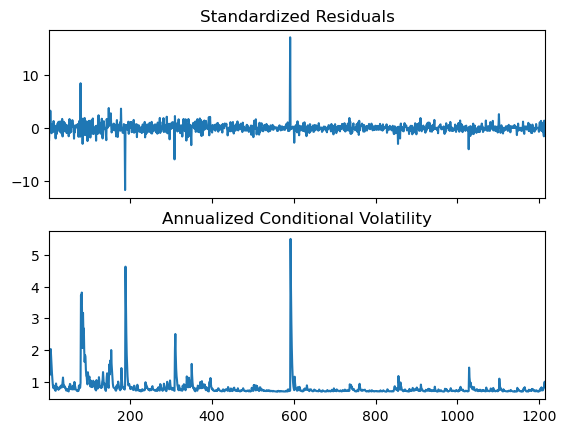

In [57]:

# Fit a GARCH(1,1) model
model = arch_model(final_returns, vol='GARCH', p=1, q=1)
results = model.fit(disp='off')

# Print summary
print(results.summary())

# Plot conditional volatility
fig = results.plot(annualize='D')
plt.show()
